In [1]:
import json 
from collections import Counter
import seaborn as sns
import pandas as pd
from pathlib import Path
import pickle
import sys
sys.path.append("..")

import matplotlib.pyplot as plt
plt.tight_layout()

<Figure size 432x288 with 0 Axes>

In [2]:
ig_path = "../models/gcn/ig_attrs.json"
shap_path = "../models/gcn/shap_values.json"

In [98]:
ig_df = pd.read_json(ig_path).T#.explode("label")

ig_df['rel_doc_ids'] = list(zip(ig_df.rel_doc_ids, ig_df.rel_doc_labels))
ig_df['rel_doc_ids'] = ig_df['rel_doc_ids'].apply(lambda x: list(zip(*x)))

shap_df = pd.read_json(shap_path).T#.explode("label")

shap_df['rel_doc_ids'] = list(zip(shap_df.rel_doc_ids, shap_df.rel_doc_labels))
shap_df['rel_doc_ids'] = shap_df['rel_doc_ids'].apply(lambda x: list(zip(*x)))

In [101]:
ig_df.explode("rel_doc_ids").rel_doc_ids.value_counts()[:10]

(901, Blutdrucksenker_beides)                492
(900, Blutdrucksenker_unklar)                491
(903, Blutdrucksenker_beides)                491
(899, Cholesterinsenker_beides)              491
(902, DM_Insulin und Tabletten)              491
(904, Cholesterinsenker_Hypercholesterin)    463
(898, Cholesterinsenker_beides)              455
(27995, Blutdrucksenker_Blutdruck)           397
(897, Cholesterinsenker_beides)              266
(896, DM_nur Tabletten)                      205
Name: rel_doc_ids, dtype: int64

In [102]:
shap_df.explode("rel_doc_ids").rel_doc_ids.value_counts()[:10]

(901, Blutdrucksenker_beides)                492
(899, Cholesterinsenker_beides)              491
(903, Blutdrucksenker_beides)                491
(900, Blutdrucksenker_unklar)                491
(902, DM_Insulin und Tabletten)              491
(904, Cholesterinsenker_Hypercholesterin)    465
(898, Cholesterinsenker_beides)              456
(27995, Blutdrucksenker_Blutdruck)           406
(897, Cholesterinsenker_beides)              251
(896, DM_nur Tabletten)                      220
Name: rel_doc_ids, dtype: int64

In [29]:
ig_df.explode("rel_doc_labels").rel_doc_labels.value_counts()

Cholesterinsenker_beides              1352
Blutdrucksenker_beides                1297
Blutdrucksenker_Blutdruck              867
DM_Insulin und Tabletten               522
Blutdrucksenker_unklar                 518
Cholesterinsenker_Hypercholesterin     472
DM_nur Tabletten                       228
Cholesterinsenker_KHK                   76
Blutdrucksenker_Herzschw                58
DM_nur Insulin                           9
Cholesterinsenker_unklar                 1
Name: rel_doc_labels, dtype: int64

In [103]:
shap_df.explode("rel_doc_labels").rel_doc_labels.value_counts()

Cholesterinsenker_beides              1334
Blutdrucksenker_beides                1278
Blutdrucksenker_Blutdruck              905
DM_Insulin und Tabletten               515
Blutdrucksenker_unklar                 506
Cholesterinsenker_Hypercholesterin     468
DM_nur Tabletten                       254
Cholesterinsenker_KHK                   71
Blutdrucksenker_Herzschw                58
DM_nur Insulin                           8
Cholesterinsenker_unklar                 3
Name: rel_doc_labels, dtype: int64

array([[<AxesSubplot:title={'center':'Blutdrucksenker_Blutdruck'}, xlabel='rel_doc_labels'>,
        <AxesSubplot:title={'center':'Blutdrucksenker_Herzschw'}, xlabel='rel_doc_labels'>,
        <AxesSubplot:title={'center':'Blutdrucksenker_beides'}, xlabel='rel_doc_labels'>,
        <AxesSubplot:title={'center':'Blutdrucksenker_unklar'}, xlabel='rel_doc_labels'>,
        <AxesSubplot:title={'center':'Cholesterinsenker_Hypercholesterin'}, xlabel='rel_doc_labels'>,
        <AxesSubplot:title={'center':'Cholesterinsenker_KHK'}, xlabel='rel_doc_labels'>],
       [<AxesSubplot:title={'center':'Cholesterinsenker_beides'}, xlabel='rel_doc_labels'>,
        <AxesSubplot:title={'center':'Cholesterinsenker_unklar'}, xlabel='rel_doc_labels'>,
        <AxesSubplot:title={'center':'DM_Insulin und Tabletten'}, xlabel='rel_doc_labels'>,
        <AxesSubplot:title={'center':'DM_nur Insulin'}, xlabel='rel_doc_labels'>,
        <AxesSubplot:title={'center':'DM_nur Tabletten'}, xlabel='rel_doc_labels'>,
 

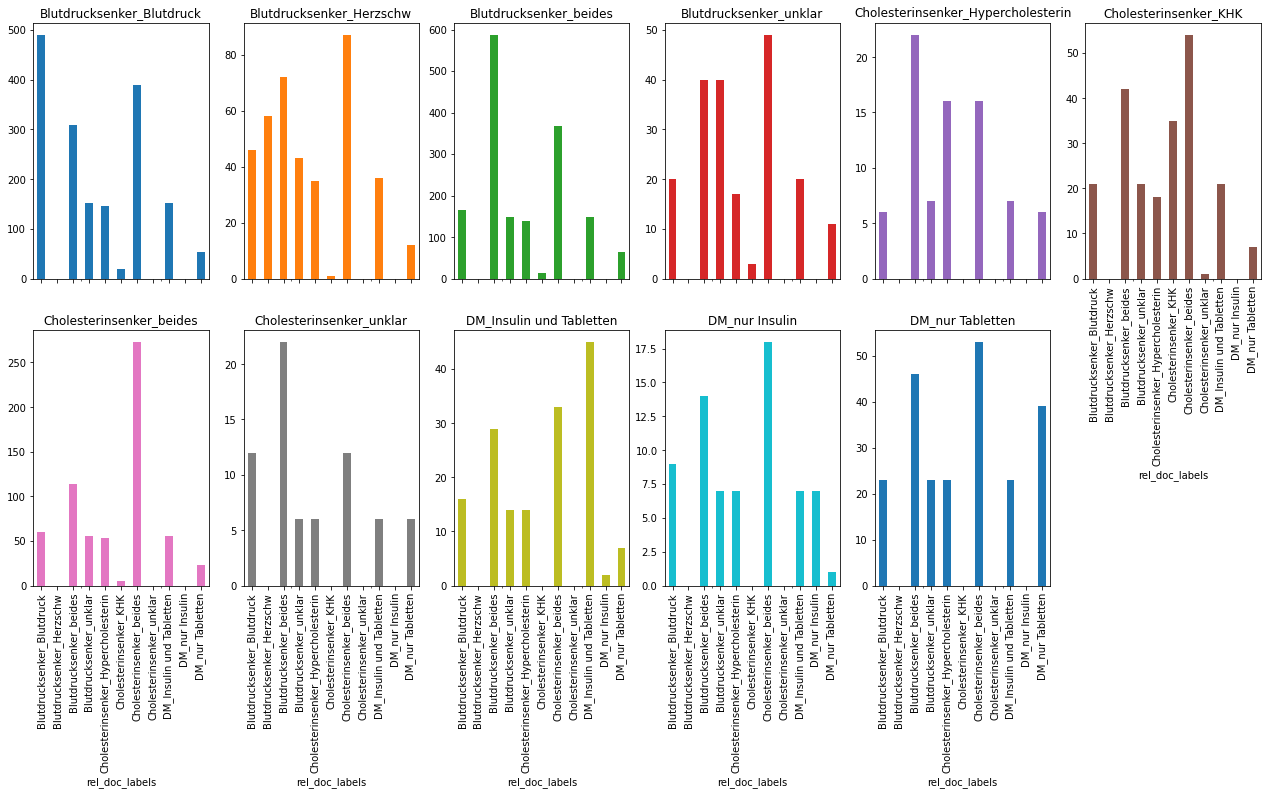

In [104]:
ig_rel_doc_labels_vc = ig_df.explode("rel_doc_labels").groupby("label")["rel_doc_labels"].value_counts()
ig_rel_doc_labels_vc.unstack(level=0).plot(kind='bar', subplots=True, rot=90, figsize=(22, 16), sharex=True, layout=(3, 6), legend=False, xlabel=None)

array([[<AxesSubplot:title={'center':'Blutdrucksenker_Blutdruck'}, xlabel='rel_doc_labels'>,
        <AxesSubplot:title={'center':'Blutdrucksenker_Herzschw'}, xlabel='rel_doc_labels'>,
        <AxesSubplot:title={'center':'Blutdrucksenker_beides'}, xlabel='rel_doc_labels'>,
        <AxesSubplot:title={'center':'Blutdrucksenker_unklar'}, xlabel='rel_doc_labels'>,
        <AxesSubplot:title={'center':'Cholesterinsenker_Hypercholesterin'}, xlabel='rel_doc_labels'>,
        <AxesSubplot:title={'center':'Cholesterinsenker_KHK'}, xlabel='rel_doc_labels'>],
       [<AxesSubplot:title={'center':'Cholesterinsenker_beides'}, xlabel='rel_doc_labels'>,
        <AxesSubplot:title={'center':'Cholesterinsenker_unklar'}, xlabel='rel_doc_labels'>,
        <AxesSubplot:title={'center':'DM_Insulin und Tabletten'}, xlabel='rel_doc_labels'>,
        <AxesSubplot:title={'center':'DM_nur Insulin'}, xlabel='rel_doc_labels'>,
        <AxesSubplot:title={'center':'DM_nur Tabletten'}, xlabel='rel_doc_labels'>,
 

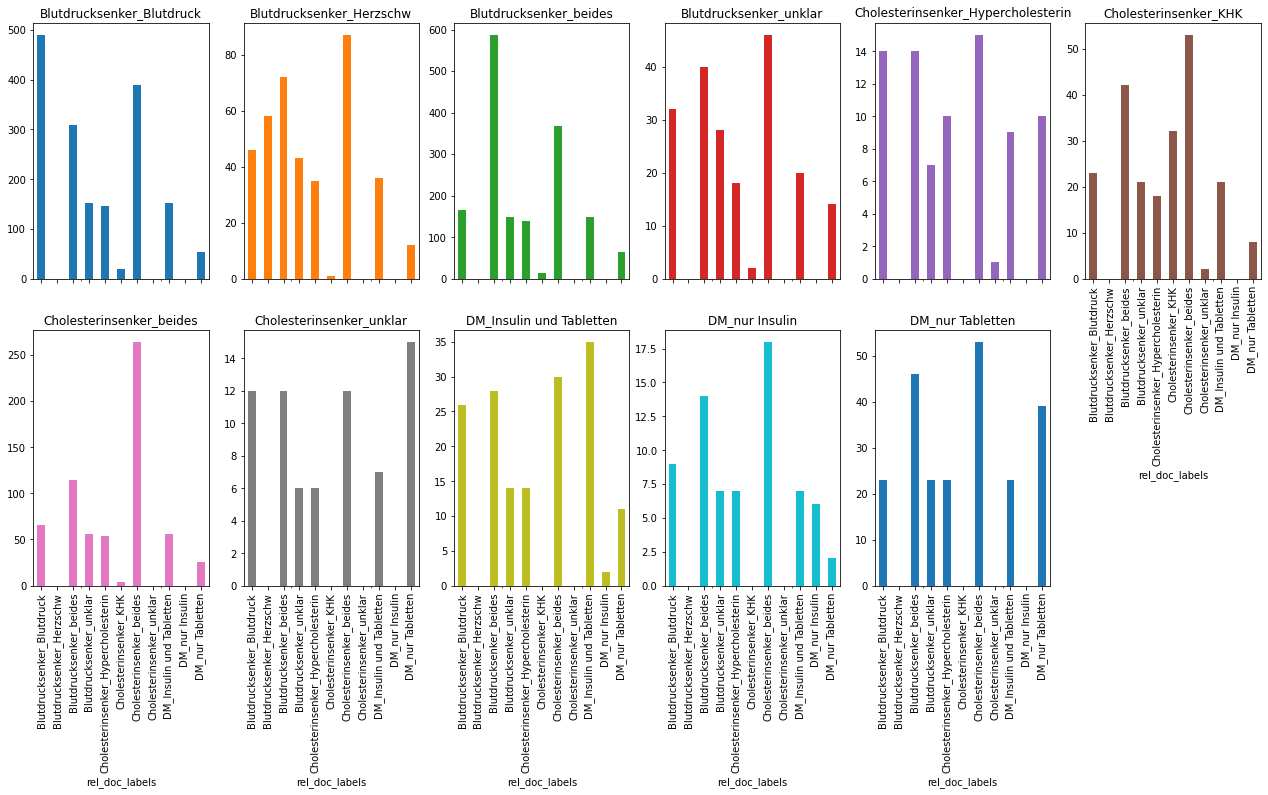

In [105]:
shap_rel_doc_labels_vc = shap_df.explode("rel_doc_labels").groupby("label")["rel_doc_labels"].value_counts()
shap_rel_doc_labels_vc.unstack(level=0).plot(kind='bar', subplots=True, rot=90, figsize=(22, 16), sharex=True, layout=(3, 6), legend=False, xlabel=None)

In [106]:
ig_rel_doc_labels_vc

label                      rel_doc_labels                    
Blutdrucksenker_Blutdruck  Blutdrucksenker_Blutdruck             490
                           Cholesterinsenker_beides              390
                           Blutdrucksenker_beides                309
                           Blutdrucksenker_unklar                152
                           DM_Insulin und Tabletten              152
                                                                ... 
DM_nur Tabletten           DM_nur Tabletten                       39
                           Blutdrucksenker_Blutdruck              23
                           Blutdrucksenker_unklar                 23
                           Cholesterinsenker_Hypercholesterin     23
                           DM_Insulin und Tabletten               23
Name: rel_doc_labels, Length: 87, dtype: int64

In [107]:
shap_rel_doc_labels_vc

label                      rel_doc_labels                    
Blutdrucksenker_Blutdruck  Blutdrucksenker_Blutdruck             490
                           Cholesterinsenker_beides              389
                           Blutdrucksenker_beides                309
                           Blutdrucksenker_unklar                152
                           DM_Insulin und Tabletten              152
                                                                ... 
DM_nur Tabletten           DM_nur Tabletten                       39
                           Blutdrucksenker_Blutdruck              23
                           Blutdrucksenker_unklar                 23
                           Cholesterinsenker_Hypercholesterin     23
                           DM_Insulin und Tabletten               23
Name: rel_doc_labels, Length: 88, dtype: int64

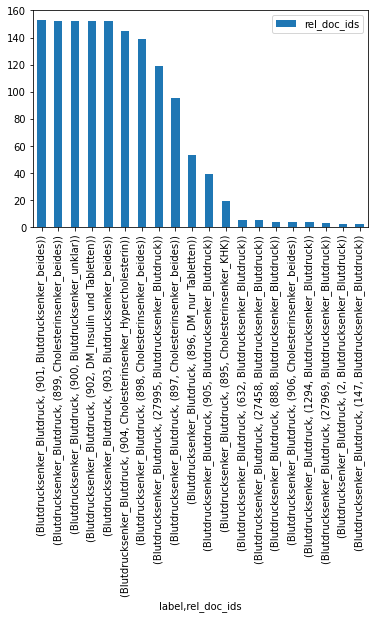

In [56]:
g = ig_df.explode("rel_doc_ids").groupby("label")["rel_doc_ids"].value_counts().to_frame().groupby(level=0)

for idx, data in g:
    data[:20].plot(kind='bar')
    break

In [77]:
ig_df.explode("rel_doc_ids").groupby("label")["rel_doc_ids"].value_counts().to_frame().rename({'rel_doc_ids': 'count',}, axis=1).reset_index(1)

,rel_doc_ids,count
label,,
Blutdrucksenker_Blutdruck,"(901, Blutdrucksenker_beides)",153
Blutdrucksenker_Blutdruck,"(899, Cholesterinsenker_beides)",152
Blutdrucksenker_Blutdruck,"(900, Blutdrucksenker_unklar)",152
Blutdrucksenker_Blutdruck,"(902, DM_Insulin und Tabletten)",152
Blutdrucksenker_Blutdruck,"(903, Blutdrucksenker_beides)",152
...,...,...
DM_nur Tabletten,"(27881, DM_nur Tabletten)",1
DM_nur Tabletten,"(27887, DM_nur Tabletten)",1
DM_nur Tabletten,"(27926, DM_nur Tabletten)",1


array([[<AxesSubplot:title={'center':'Blutdrucksenker_Blutdruck'}>,
        <AxesSubplot:title={'center':'Blutdrucksenker_Herzschw'}>,
        <AxesSubplot:title={'center':'Blutdrucksenker_beides'}>,
        <AxesSubplot:title={'center':'Blutdrucksenker_unklar'}>,
        <AxesSubplot:title={'center':'Cholesterinsenker_Hypercholesterin'}>,
        <AxesSubplot:title={'center':'Cholesterinsenker_KHK'}>],
       [<AxesSubplot:title={'center':'Cholesterinsenker_beides'}>,
        <AxesSubplot:title={'center':'Cholesterinsenker_unklar'}>,
        <AxesSubplot:title={'center':'DM_Insulin und Tabletten'}>,
        <AxesSubplot:title={'center':'DM_nur Insulin'}>,
        <AxesSubplot:title={'center':'DM_nur Tabletten'}>,
        <AxesSubplot:>],
       [<AxesSubplot:>, <AxesSubplot:>, <AxesSubplot:>, <AxesSubplot:>,
        <AxesSubplot:>, <AxesSubplot:>]], dtype=object)

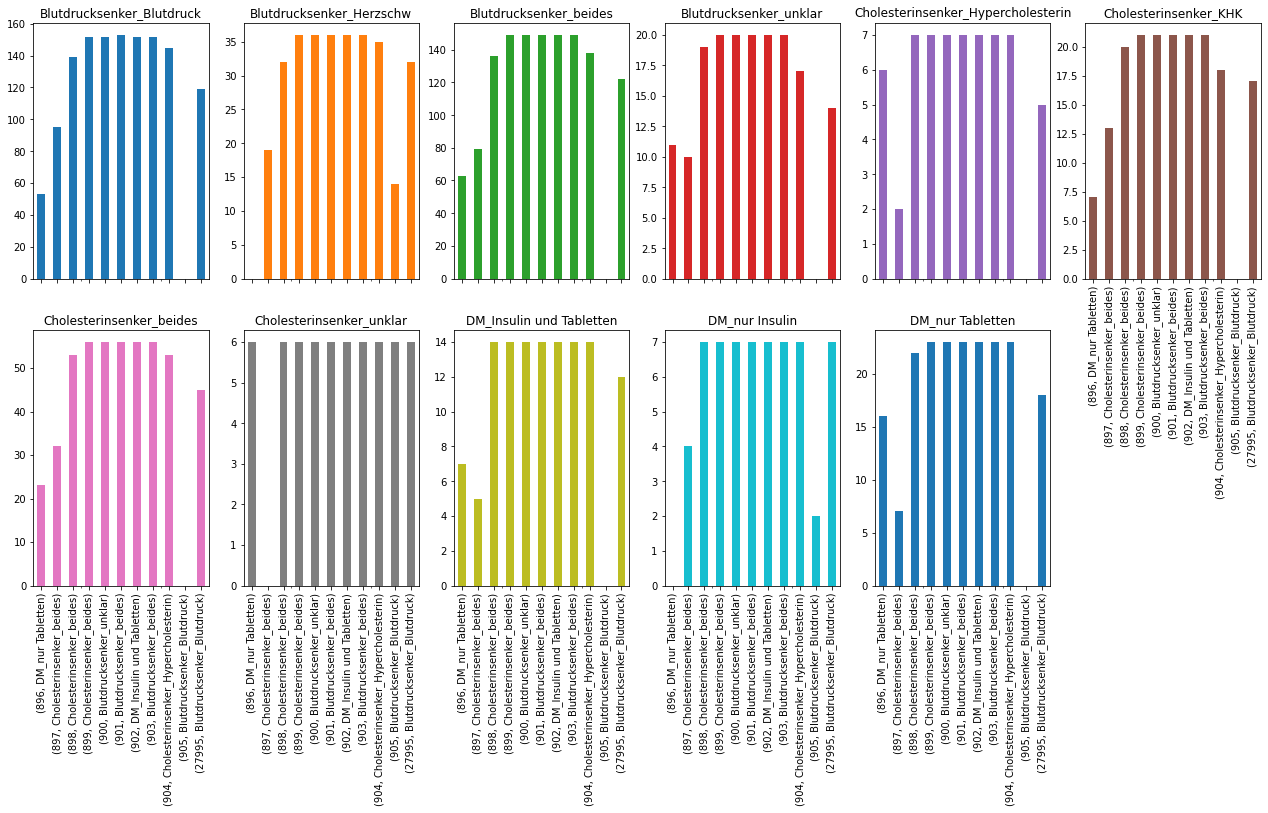

In [93]:
rel_doc_ids_vc = ig_df.explode("rel_doc_ids").groupby("label")["rel_doc_ids"].value_counts()
rel_doc_ids_vc.unstack(0).T.apply(pd.Series.nlargest, axis=1, n=10).T.plot(
    kind='bar', subplots=True, rot=90, figsize=(22, 16), sharex=True, layout=(3, 6), legend=False, xticks=None)#xlabel=None, xticks=None, use_index=False)


In [88]:
rel_doc_ids_vc.unstack(0).T.apply(pd.Series.nlargest, axis=1, n=10)

,896,897,898,899,900,901,902,903,904,905,27995
,DM_nur Tabletten,Cholesterinsenker_beides,Cholesterinsenker_beides,Cholesterinsenker_beides,Blutdrucksenker_unklar,Blutdrucksenker_beides,DM_Insulin und Tabletten,Blutdrucksenker_beides,Cholesterinsenker_Hypercholesterin,Blutdrucksenker_Blutdruck,Blutdrucksenker_Blutdruck
label,,,,,,,,,,,
Blutdrucksenker_Blutdruck,53.0,95.0,139.0,152.0,152.0,153.0,152.0,152.0,145.0,NaN,119.0
Blutdrucksenker_Herzschw,NaN,19.0,32.0,36.0,36.0,36.0,36.0,36.0,35.0,14.0,32.0
Blutdrucksenker_beides,63.0,79.0,136.0,149.0,149.0,149.0,149.0,149.0,138.0,NaN,122.0
Blutdrucksenker_unklar,11.0,10.0,19.0,20.0,20.0,20.0,20.0,20.0,17.0,NaN,14.0
Cholesterinsenker_Hypercholesterin,6.0,2.0,7.0,7.0,7.0,7.0,7.0,7.0,7.0,NaN,5.0
Cholesterinsenker_KHK,7.0,13.0,20.0,21.0,21.0,21.0,21.0,21.0,18.0,NaN,17.0
Cholesterinsenker_beides,23.0,32.0,53.0,56.0,56.0,56.0,56.0,56.0,53.0,NaN,45.0
Cholesterinsenker_unklar,6.0,NaN,6.0,6.0,6.0,6.0,6.0,6.0,6.0,6.0,6.0
